In [1]:
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.mask import mask
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from typing import Tuple, List, Dict
from tqdm import tqdm
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
import numpy as np
import numpy as np
import random
import json
from pathlib import Path
from typing import Dict, List, Tuple
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from typing import Dict, Tuple
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from pathlib import Path

from data_loader import (
    load_dem, load_infiltration_map, load_landuse_map, print_raster_stats,gmm_no_manila_path_box_load_all_flood_maps,
    load_all_rainfall_scenarios, get_rainfall_stats, visualize_raster, visualize_flood_maps_grid, manila_path_shape_load_all_flood_maps,
    get_raster_stats, load_manila_mask, gmm_path_load_all_flood_maps
)

from data_preprocessing import (normalize_dem, normalize_infiltration, normalize_landuse, handle_nodata )

from flood_maps import (FLOOD_CLASSES, reconstruct_map_from_patches, categorize_all_flood_maps_patch, visualize_all_categorized_maps)

from quadrant import ( stack_spatial_inputs, split_into_quadrants, build_train_test_split, extract_spatial_patches, get_quadrant_patch_indices, visualize_quadrant_split )

from vit import ViT

from training import FloodPatchDataset, train_kfold

RANDOM_SEED = 42
NUM_SCENARIO = 50
NUM_CLASSES  = 5

PATCH_SIZE = 4
EMBED_DIM  = 256
NUM_HEADS  = 8
NUM_LAYERS = 4
BATCH_SIZE = 1024   
NUM_EPOCHS = 50     
NUM_FOLDS  = 10
LR         = 3e-4

In [2]:
repo_root = os.getcwd()
gmm_path = os.path.join(repo_root, "COP-30m-GMM")
gmm_no_manila_path = os.path.join(repo_root, "COP-30m-GMM-ManilaMaskOut")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rainfall_path = os.path.join(repo_root, "mm_hr_scenarios")

# Loading data


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -9.1316
Max value:     466.3908
Mean value:    42.0699
Std dev:       69.0678
Valid pixels:  1,377,000 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     3.6847
Mean value:    0.4818
Std dev:       0.9485
Valid pixels:  1,377,000 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    4.9338
Std dev:       2.5013
Valid pixels:  1,377,000 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 11

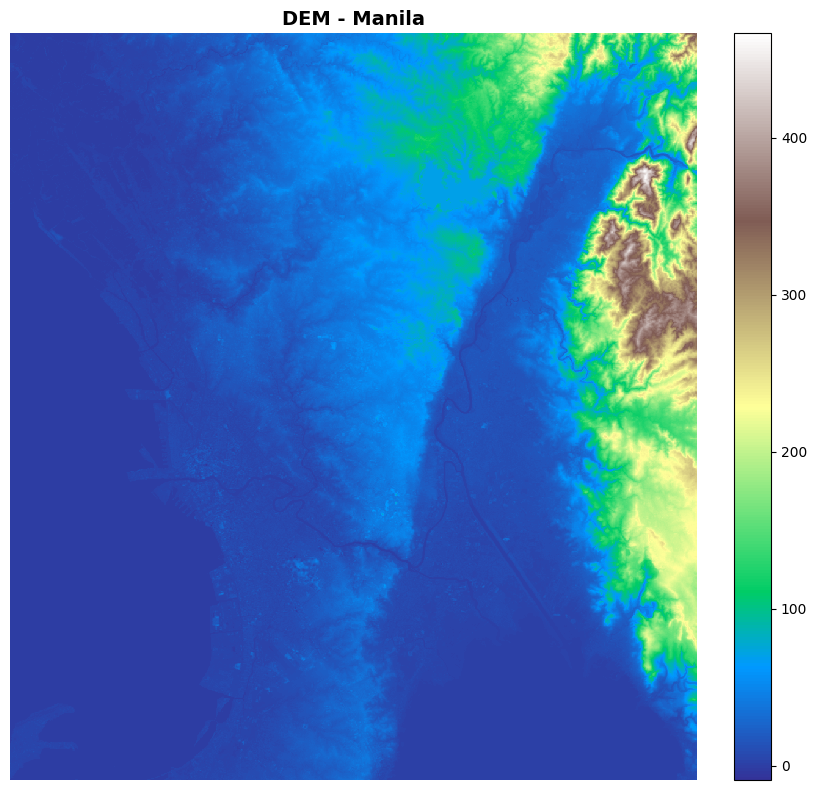

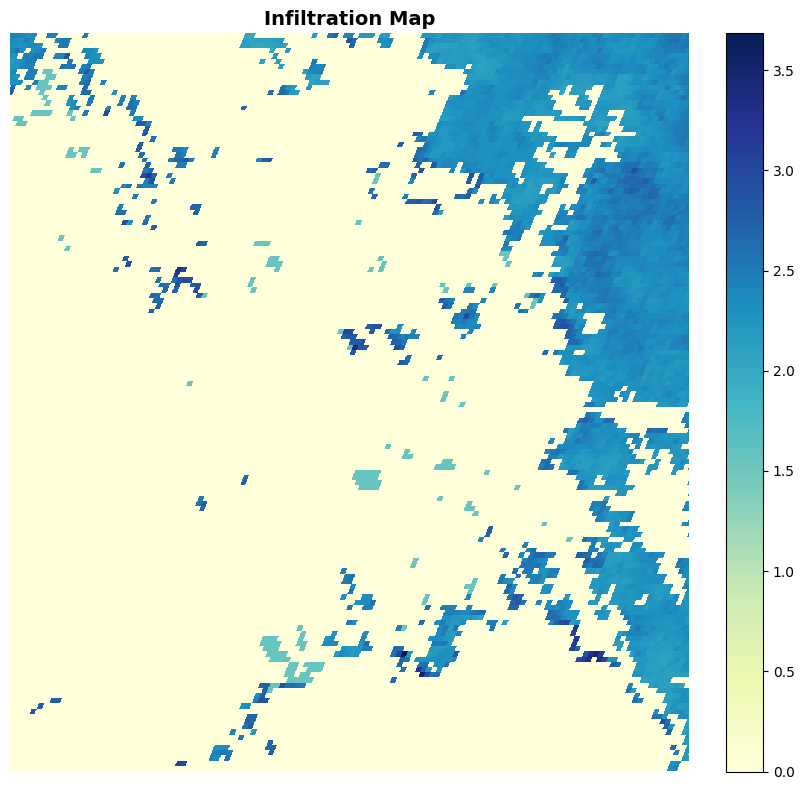

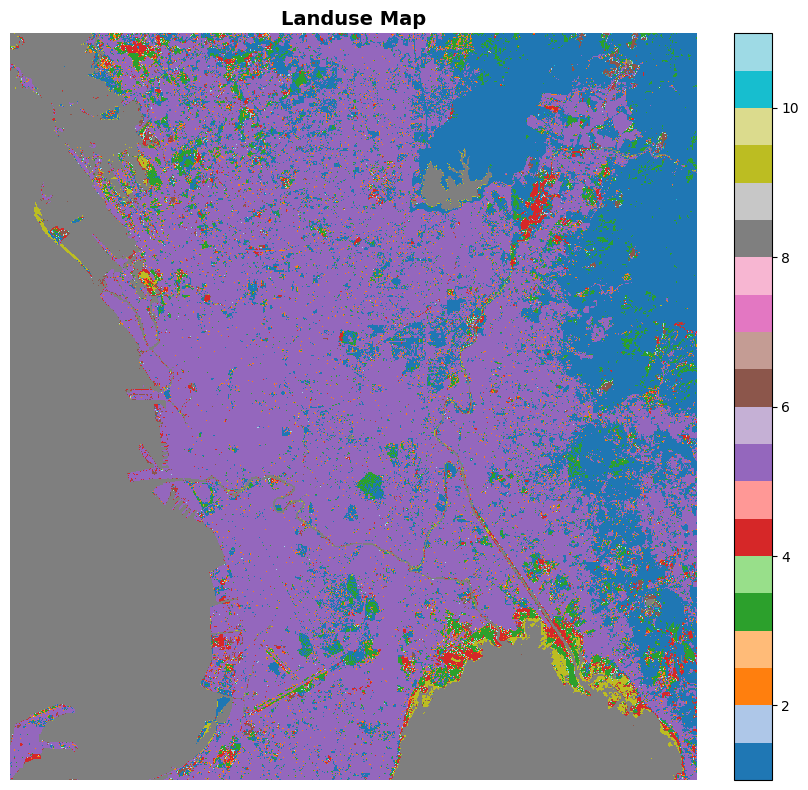

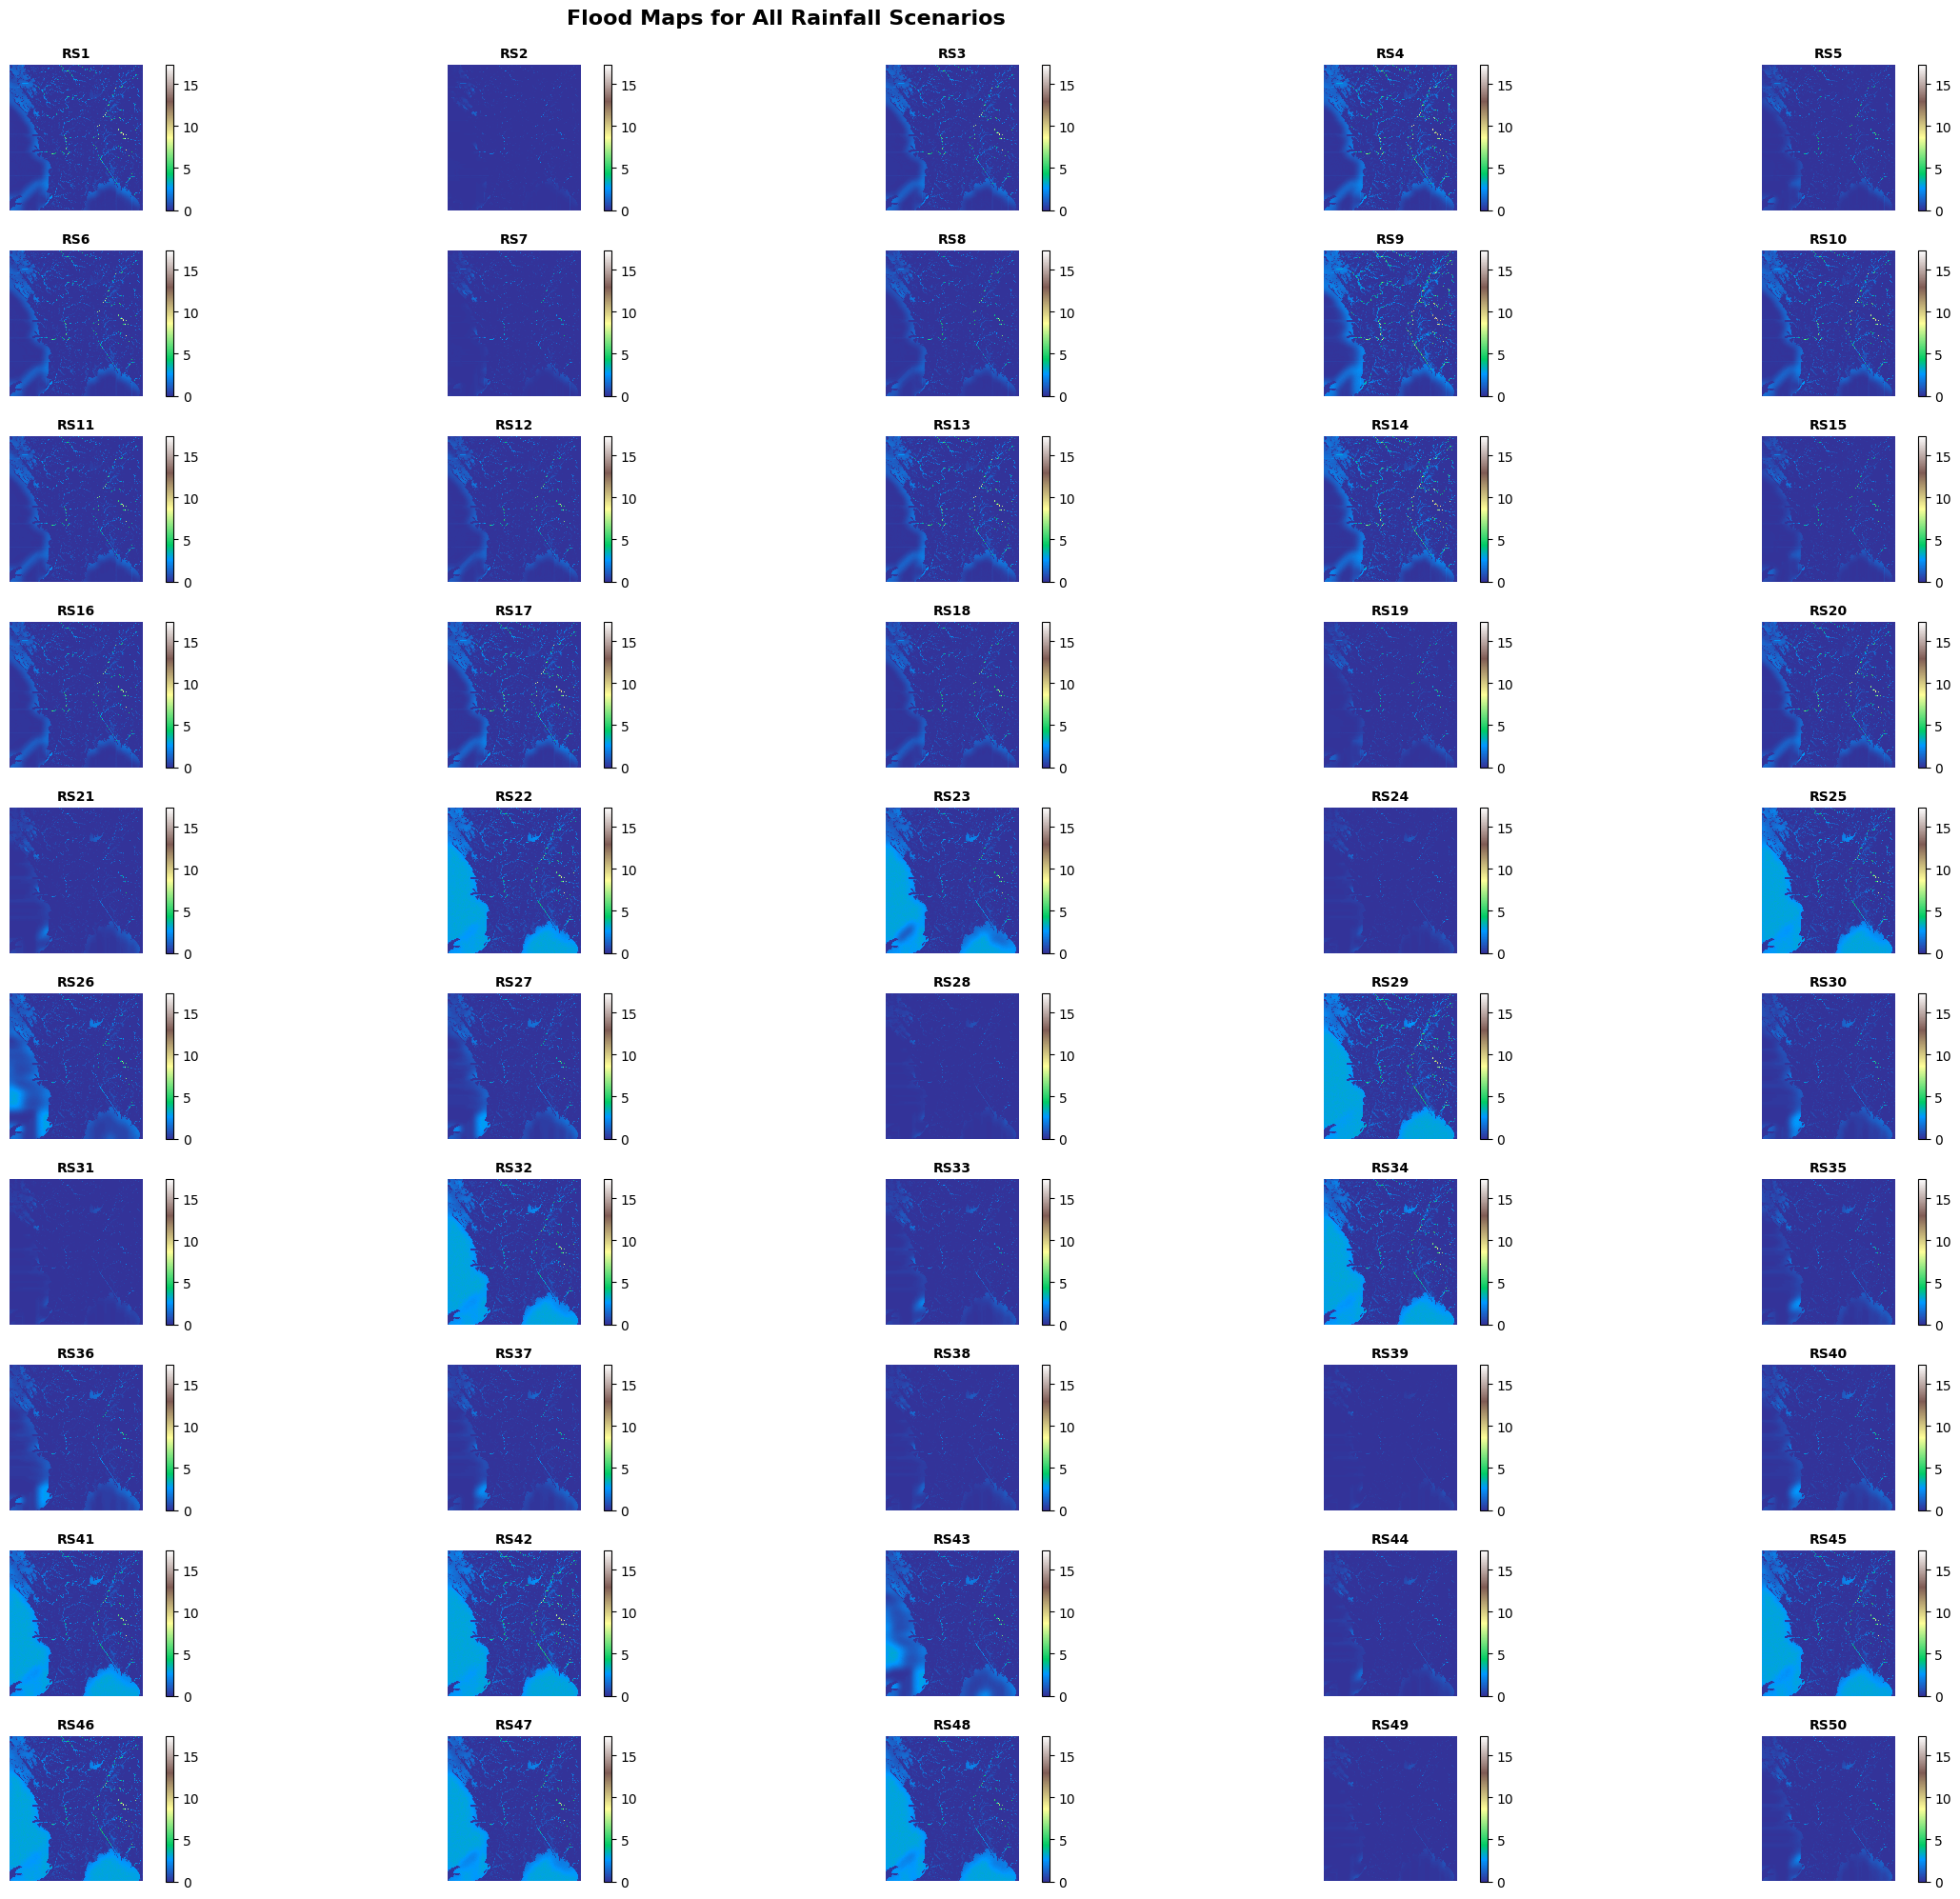

In [3]:
# Load DEM
print("\n--- Loading DEM ---")
dem_path = os.path.join(gmm_path, "greater_mm_bbox_dem_cop.tif")
if os.path.exists(dem_path):
    dem_data, dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(dem_data, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")
    dem_data = None

fig1 = visualize_raster(dem_data, title="DEM - Manila", cmap='terrain')

# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(gmm_path, "GM_Infilt_fixed.tif")
if os.path.exists(infilt_path):
    infilt_data, infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(infilt_data, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data = None
fig2 = visualize_raster(infilt_data, title="Infiltration Map", cmap='YlGnBu')

# Load Landuse Map
print("\n--- Loading Landuse Map ---")
landuse_path =  os.path.join(gmm_path, "GM_LU.tif")
if os.path.exists(landuse_path):
    landuse_data, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(landuse_data, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data = None
    
fig3 = visualize_raster(landuse_data, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(gmm_path, "exp-des-4")
flood_maps, flood_metadata = gmm_path_load_all_flood_maps(gmm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps)}")
    
    if len(flood_maps) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

fig4 = visualize_flood_maps_grid(flood_maps=flood_maps,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)

In [4]:
print("LOADING RAINFALL SCENARIOS")
# Load rainfall scenarios
rainfall_scenarios = load_all_rainfall_scenarios(rainfall_path)

if len(rainfall_scenarios) > 0:
    print(f"\nRainfall scenarios successfully loaded: {len(rainfall_scenarios)}")
    
    if len(rainfall_scenarios) >= NUM_SCENARIO:
        rain_stats = get_rainfall_stats(rainfall_scenarios[-1], scenario_id=20)
else:
    print("WARNING: No rainfall scenarios loaded!")

display(rainfall_scenarios)

LOADING RAINFALL SCENARIOS
Rainfall Scenario 10 loaded: 13 time steps
Rainfall Scenario 11 loaded: 13 time steps
Rainfall Scenario 12 loaded: 13 time steps
Rainfall Scenario 13 loaded: 13 time steps
Rainfall Scenario 14 loaded: 13 time steps
Rainfall Scenario 15 loaded: 13 time steps
Rainfall Scenario 16 loaded: 13 time steps
Rainfall Scenario 17 loaded: 13 time steps
Rainfall Scenario 18 loaded: 13 time steps
Rainfall Scenario 19 loaded: 13 time steps
Rainfall Scenario 1 loaded: 13 time steps
Rainfall Scenario 20 loaded: 13 time steps
Rainfall Scenario 21 loaded: 13 time steps
Rainfall Scenario 22 loaded: 13 time steps
Rainfall Scenario 23 loaded: 13 time steps
Rainfall Scenario 24 loaded: 13 time steps
Rainfall Scenario 25 loaded: 13 time steps
Rainfall Scenario 26 loaded: 13 time steps
Rainfall Scenario 27 loaded: 13 time steps
Rainfall Scenario 28 loaded: 13 time steps
Rainfall Scenario 29 loaded: 13 time steps
Rainfall Scenario 2 loaded: 13 time steps
Rainfall Scenario 30 loaded: 

[        hour  intensity_mmhr
 0   0.000000       42.858193
 1   0.083333       89.355428
 2   0.166667       99.794571
 3   0.250000       89.539823
 4   0.333333       69.779853
 5   0.416667       48.115899
 6   0.500000       29.149869
 7   0.583333       15.072448
 8   0.666667        6.251203
 9   0.750000        1.818679
 10  0.833333        0.260511
 11  0.916667        0.003522
 12  1.000000        0.000000,
         hour  intensity_mmhr
 0   0.000000        3.789265
 1   0.083333       17.178059
 2   0.166667       31.808902
 3   0.250000       44.594748
 4   0.333333       53.884509
 5   0.416667       58.744516
 6   0.500000       58.744516
 7   0.583333       53.884509
 8   0.666667       44.594748
 9   0.750000       31.808902
 10  0.833333       17.178059
 11  0.916667        3.789265
 12  1.000000        0.000000,
         hour  intensity_mmhr
 0   0.000000        3.031412
 1   0.083333       13.742447
 2   0.166667       25.447122
 3   0.250000       35.675799
 4   0.3

# Data Preprocessing

In [5]:
print("\nProcessing DEM...")
dem_clean = handle_nodata(dem_data, nodata_value=dem_meta.get('nodata'), fill_method='mean')

print("\nProcessing Infiltration...")
infilt_clean = handle_nodata(infilt_data, nodata_value=infilt_meta.get('nodata'), fill_method='mean')

print("\nProcessing Landuse...")
landuse_clean = handle_nodata(landuse_data, nodata_value=landuse_meta.get('nodata'), fill_method='interpolate')


Processing DEM...

Handling NoData for Raster...
  NoData pixels: 0 / 1,377,000 (0.00%)
  ✓ No NoData values found

Processing Infiltration...

Handling NoData for Raster...
  NoData pixels: 0 / 1,377,000 (0.00%)
  ✓ No NoData values found

Processing Landuse...

Handling NoData for Raster...
  NoData pixels: 0 / 1,377,000 (0.00%)
  ✓ No NoData values found


In [6]:
# Normalize DEM
print("\nNormalizing DEM...")
dem_normalized, dem_params = normalize_dem(dem_data, method='minmax')
# Verify normalization
dem_norm_stats = get_raster_stats(dem_normalized, "DEM (Normalized)")
print_raster_stats(dem_norm_stats)

# Normalize Infiltration
print("\nNormalizing Infiltration...")
infilt_normalized, infilt_params = normalize_infiltration(infilt_data)
# Verify normalization
infilt_norm_stats = get_raster_stats(infilt_normalized, "Infiltration (Normalized)")
print_raster_stats(infilt_norm_stats)

# Normalize Landuse
print("\nNormalizing Landuse...")
landuse_normalized, landuse_params = normalize_landuse(landuse_data, method='minmax')
# Verify normalization
landuse_norm_stats = get_raster_stats(landuse_normalized, "Landuse (Normalized)")
print_raster_stats(landuse_norm_stats)



Normalizing DEM...
DEM normalized (min-max): [-9.1316, 466.3908] -> [0.0, 1.0]

Statistics for: DEM (Normalized)
Shape:         (1224, 1125)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.1077
Std dev:       0.1452
Valid pixels:  1,377,000 / 1,377,000


Normalizing Infiltration...
Infiltration normalized (min-max): [0.0000, 3.6847] -> [0.0, 1.0]

Statistics for: Infiltration (Normalized)
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.1308
Std dev:       0.2574
Valid pixels:  1,377,000 / 1,377,000


Normalizing Landuse...
Landuse normalized (min-max): [1.0000, 11.0000] -> [0.0, 1.0]

Statistics for: Landuse (Normalized)
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.3934
Std dev:       0.2501
Valid pixels:  1,377,000 / 1,377,000



# Flood Maps (Ground Truths)

In [7]:
flood_maps_categorized_patch, patch_metadata = categorize_all_flood_maps_patch(flood_maps, patch_size=PATCH_SIZE, stride=None, categorization_method='majority', verbose=True)


PATCH-BASED FLOOD MAP CATEGORIZATION

Configuration:
  Patch size: 4×4
  Stride: 4 (non-overlapping)
  Categorization method: majority

Class definitions:
  Class 0: No Flood     [0.00, 0.15) m
  Class 1: Light        [0.15, 0.24) m
  Class 2: Moderate     [0.24, 0.46) m
  Class 3: Heavy        [0.46, 0.68) m
  Class 4: Extreme      [0.68, ∞) m

Scenario  1 (85986 patches):
  No Flood    : 64,152 patches (74.61%)
  Light       :  1,892 patches ( 2.20%)
  Moderate    :  3,905 patches ( 4.54%)
  Heavy       :  2,618 patches ( 3.04%)
  Extreme     : 13,419 patches (15.61%)
Scenario  2 (85986 patches):
  No Flood    : 82,402 patches (95.83%)
  Light       :  1,322 patches ( 1.54%)
  Moderate    :  1,553 patches ( 1.81%)
  Heavy       :    364 patches ( 0.42%)
  Extreme     :    345 patches ( 0.40%)
Scenario  3 (85986 patches):
  No Flood    : 64,911 patches (75.49%)
  Light       :  1,993 patches ( 2.32%)
  Moderate    :  3,906 patches ( 4.54%)
  Heavy       :  2,737 patches ( 3.18%)
  Ex

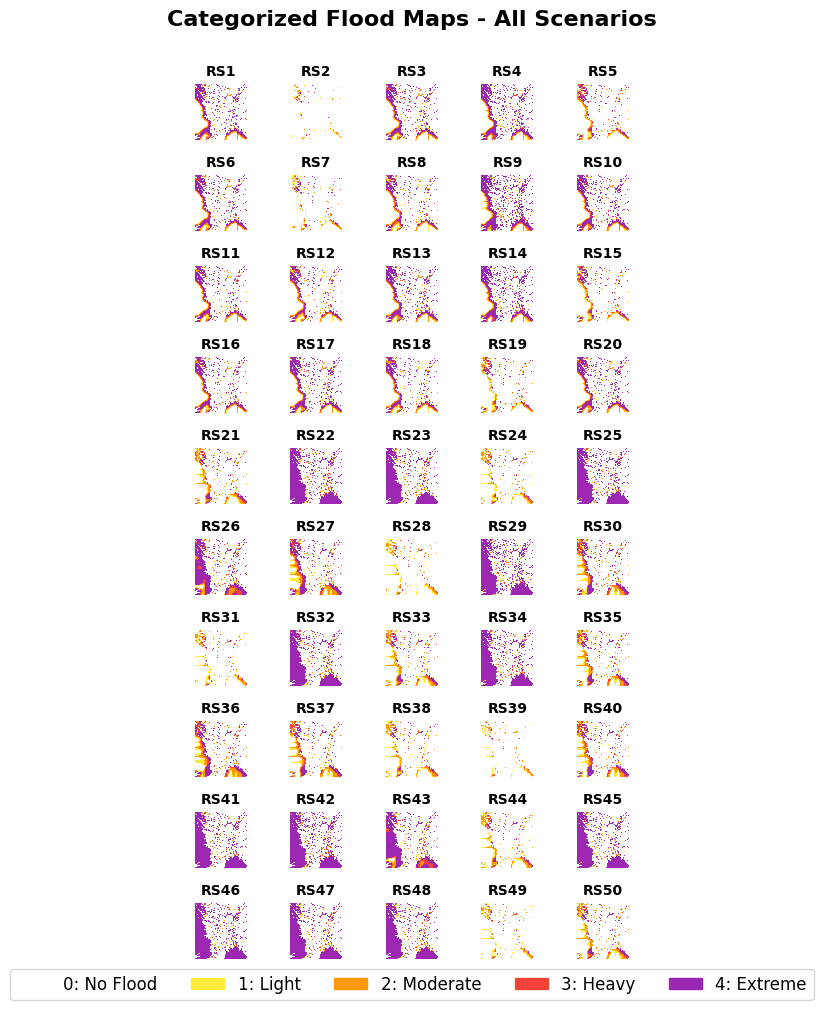

In [8]:
reconstructed_maps = []
for patch_labels, metadata in zip(flood_maps_categorized_patch, patch_metadata):
    reconstructed = reconstruct_map_from_patches(patch_labels, metadata, method='nearest')
    reconstructed_maps.append(reconstructed)
fig_all = visualize_all_categorized_maps(reconstructed_maps, scenario_ids=list(range(1, 51)), figsize=(5, 10), ncols=5)
plt.show()

In [9]:
display(flood_maps_categorized_patch)

[array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([2, 2, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([3, 3, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([2, 2, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([3, 3, 0, ..., 0, 0, 0], shape=(85986,), dtype=int8),
 array([4, 4, 0, ..., 0,

# Data Splitting Strategy

In [10]:
print("Stack Spatial Inputs")
spatial_stack = stack_spatial_inputs(dem_normalized, infilt_normalized, landuse_normalized)

print("Flood maps already categorized →", len(flood_maps_categorized_patch), "scenarios")

print("Quadrant Split — Spatial Stack")
spatial_quadrants = split_into_quadrants(spatial_stack)

print("\nExtract Spatial Patches (full map)")
spatial_patches = extract_spatial_patches(spatial_stack, patch_size=PATCH_SIZE)

print("\nCompute Quadrant Patch Indices")
H, W = dem_normalized.shape
quadrant_indices = get_quadrant_patch_indices(H, W, patch_size=PATCH_SIZE)

print("\nBuild Train / Test Split")
dataset = build_train_test_split(spatial_patches, flood_maps_categorized_patch, quadrant_indices, rainfall_scenarios=rainfall_scenarios,)

Stack Spatial Inputs
[Stack] Spatial input shape: (1224, 1125, 3)  |  Channels: DEM, Infiltration, Landuse
Flood maps already categorized → 50 scenarios
Quadrant Split — Spatial Stack
  [Q1 | TRAIN] shape: (612, 562, 3)
  [Q2 | TRAIN] shape: (612, 562, 3)
  [Q3 | TEST] shape: (612, 562, 3)
  [Q4 | TRAIN] shape: (612, 562, 3)

Extract Spatial Patches (full map)
  Spatial patches extracted: 85,986  shape: (85986, 4, 4, 3)

Compute Quadrant Patch Indices
  [Q1 | TRAIN] 21,420 patches
  [Q2 | TRAIN] 21,573 patches
  [Q3 | TEST] 21,420 patches
  [Q4 | TRAIN] 21,573 patches

Build Train / Test Split

QUADRANT SPLIT SUMMARY
  Train quadrants  : ['Q1', 'Q2', 'Q4']
  Test  quadrants  : ['Q3']
  X_train          : (64566, 4, 4, 3)  (patches, h, w, C)
  X_test           : (21420, 4, 4, 3)   (patches, h, w, C)
  y_train          : (50, 64566)  (scenarios, patches)  — int8 class
  y_test           : (50, 21420)   (scenarios, patches)  — int8 class
  Rainfall         : 50 scenarios (NOT split spatia

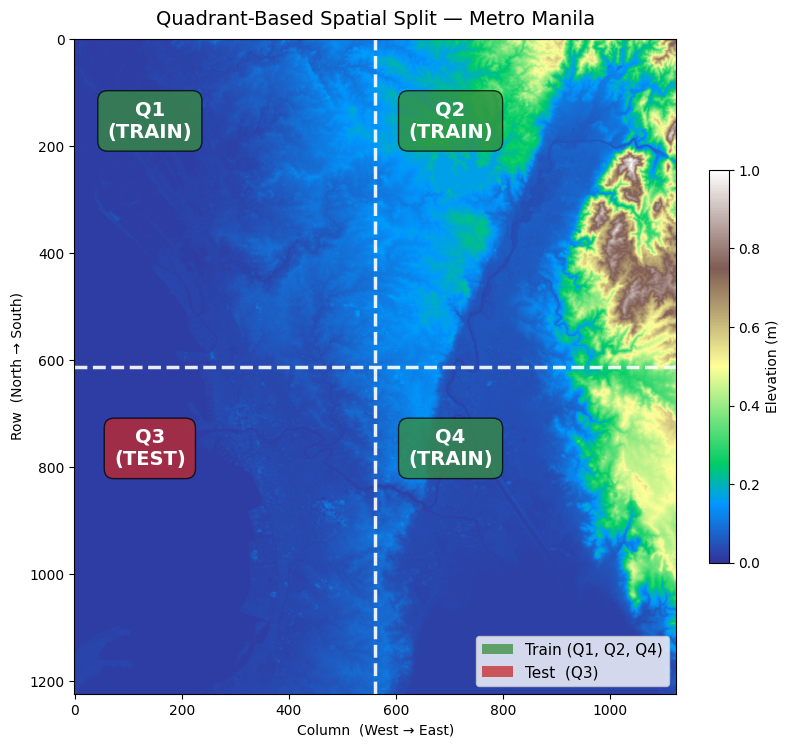

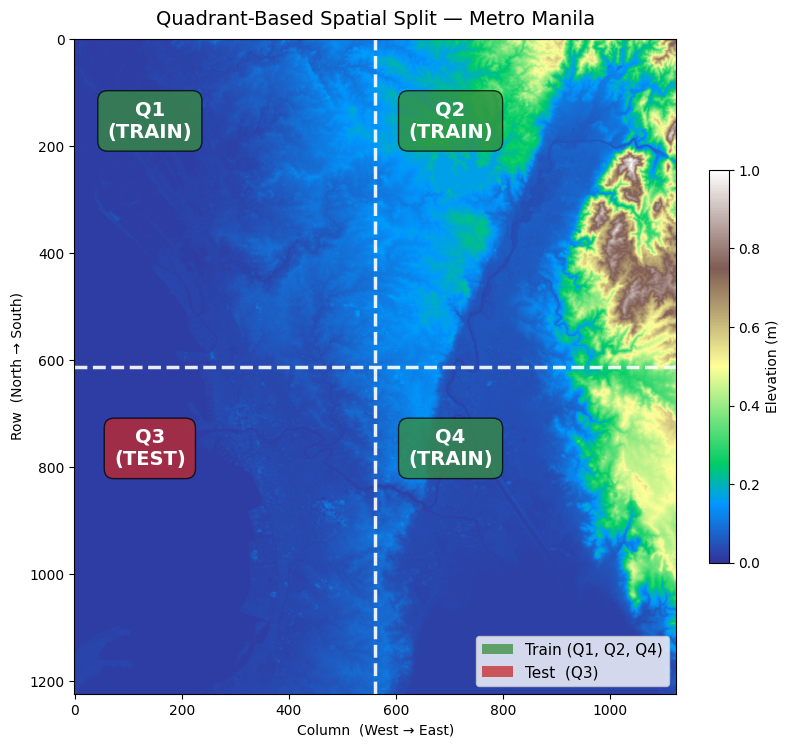

In [11]:
visualize_quadrant_split(dem_normalized)

# Rainfall Encoding

In [12]:
all_intensities = np.concatenate([df['intensity_mmhr'].values for df in rainfall_scenarios])
rain_min, rain_max = all_intensities.min(), all_intensities.max()

def normalize_rainfall_scenarios_full(rainfall_scenarios, rain_min, rain_max):
    normalized = []
    for df in rainfall_scenarios:
        intensity = (df['intensity_mmhr'].values - rain_min) / (rain_max - rain_min + 1e-8)
        hour = df['hour'].values / 23.0   # normalize 0-23 → 0-1
        combined = np.concatenate([intensity, hour]).astype(np.float32)
        normalized.append(combined)
    return np.stack(normalized, axis=0)   # (50, 26)

rain_embeddings = normalize_rainfall_scenarios_full(rainfall_scenarios, rain_min, rain_max)
print(rain_embeddings.shape)


(50, 26)


# ViT Config

In [13]:
from config import Config
from model_config import model_factory, make_model
from training import FloodPatchDataset, train_kfold

cfg = Config()  
cfg.save(cfg.train.output_dir / 'config.json')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = FloodPatchDataset(
    X_spatial = dataset['X_train'],
    y_labels  = dataset['y_train'],
    rainfall  = rain_embeddings,
)

[FloodPatchDataset]
  Spatial tokens : torch.Size([64566, 3, 4, 4])  (N_patches, C, H, W)
  Labels         : torch.Size([64566, 50])  (N_patches, N_scenarios)
  Rainfall       : torch.Size([50, 26])  (N_scenarios, 26)
  Total samples  : 3,228,300  (patches × scenarios)


# Training Setup

In [14]:
# ── K-Fold Training ─────────────────────────────────────────────────────
fold_histories, best_fold = train_kfold(
    model_factory = model_factory(cfg.model),
    full_dataset  = train_dataset,
    y_train       = dataset['y_train'],
    cfg           = cfg.train,
    device        = device,
)

Class weights (inverse frequency):
  Class 0 (No Flood  ): 78.12% of patches  →  weight 0.0538
  Class 1 (Light     ):  2.11% of patches  →  weight 1.9965
  Class 2 (Moderate  ):  4.14% of patches  →  weight 1.0158
  Class 3 (Heavy     ):  2.61% of patches  →  weight 1.6113
  Class 4 (Extreme   ): 13.03% of patches  →  weight 0.3226

FOLD 1 / 2
  Train samples : 1,614,150
  Val   samples : 1,614,150
    [TRAIN] batch  1000/1577  loss=1.4173  acc=0.7189
    [TRAIN] batch  1577/1577  loss=1.4101  acc=0.7253
    [VAL  ] batch  1000/1577  loss=1.3999  acc=0.7301
    [VAL  ] batch  1577/1577  loss=1.4005  acc=0.7300
  Epoch  1/1  train_loss=1.4101  train_acc=0.7253  val_loss=1.4005  val_acc=0.7300

  ✓ Fold 1 best val acc: 0.7300

FOLD 2 / 2
  Train samples : 1,614,150
  Val   samples : 1,614,150
    [TRAIN] batch  1000/1577  loss=1.4152  acc=0.7258
    [TRAIN] batch  1577/1577  loss=1.4086  acc=0.7298
    [VAL  ] batch  1000/1577  loss=1.4076  acc=0.7416
    [VAL  ] batch  1577/1577  loss=

In [15]:
# Loading best model
ckpt  = torch.load(cfg.train.output_dir / f'fold_{best_fold+1}' / 'best_model.pt', map_location=device)
model = make_model(cfg.model)
model.load_state_dict(ckpt['model_state_dict'])
model.to(device).eval()
print(f"✓ Loaded fold {best_fold+1}  (val_acc={ckpt['best_val_acc']:.4f})")

✓ Loaded fold 2  (val_acc=0.7418)


# Testing

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from testing import ( prepare_ground_truth, evaluate_all_scenarios, plot_metrics_summary, plot_per_scenario_metrics,plot_per_class_metrics, plot_flood_on_dem )

print("\nPreparing ground truth maps for test scenarios...")
ground_truth = prepare_ground_truth(
    y_test           = dataset['y_test'],     
    quadrant_indices = quadrant_indices,
    patch_metadata   = patch_metadata[0],
)


Preparing ground truth maps for test scenarios...

Preparing ground truth maps for test scenarios...
  Q3 patch grid : 153 rows × 140 cols = 21420 patches
  GT maps shape : (50, 153, 140)  ✓


In [17]:
print("\nEvaluating all test scenarios...")
results = evaluate_all_scenarios(
    model           = model,
    X_test          = dataset['X_test'],
    y_test          = dataset['y_test'],
    rain_normalized = rain_embeddings,
    ground_truth    = ground_truth,
    batch_size      = 512,
    device          = device,
    num_classes     = cfg.model.num_classes,
)


Evaluating all test scenarios...

Evaluating all test scenarios...
  RS01  Acc=0.4956  Prec=0.2669  Rec=0.2873  F1=0.2288  IoU=0.1573
  RS02  Acc=0.3723  Prec=0.2063  Rec=0.2502  F1=0.1198  IoU=0.0808
  RS03  Acc=0.4878  Prec=0.2709  Rec=0.2902  F1=0.2275  IoU=0.1555
  RS04  Acc=0.3543  Prec=0.2628  Rec=0.2763  F1=0.1739  IoU=0.1175
  RS05  Acc=0.4084  Prec=0.2413  Rec=0.2808  F1=0.1708  IoU=0.1136
  RS06  Acc=0.4854  Prec=0.2710  Rec=0.2904  F1=0.2264  IoU=0.1547
  RS07  Acc=0.3756  Prec=0.2171  Rec=0.2524  F1=0.1346  IoU=0.0907
  RS08  Acc=0.4058  Prec=0.2564  Rec=0.2954  F1=0.1861  IoU=0.1253
  RS09  Acc=0.5441  Prec=0.2922  Rec=0.2905  F1=0.2647  IoU=0.1875
  RS10  Acc=0.4959  Prec=0.2742  Rec=0.2881  F1=0.2333  IoU=0.1595
  RS11  Acc=0.4775  Prec=0.2623  Rec=0.2919  F1=0.2183  IoU=0.1496
  RS12  Acc=0.4159  Prec=0.2608  Rec=0.2993  F1=0.1885  IoU=0.1284
  RS13  Acc=0.4947  Prec=0.2759  Rec=0.2888  F1=0.2339  IoU=0.1597
  RS14  Acc=0.3581  Prec=0.2648  Rec=0.2760  F1=0.1736  IoU=0


Generating visualizations...


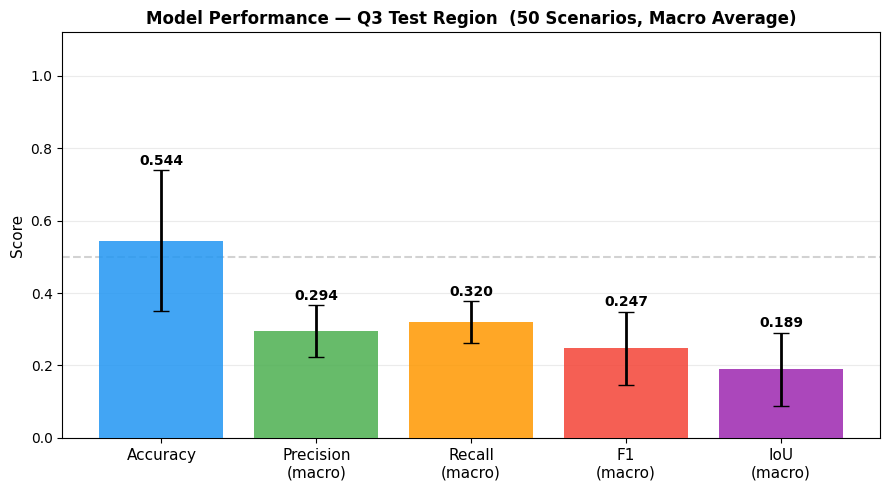

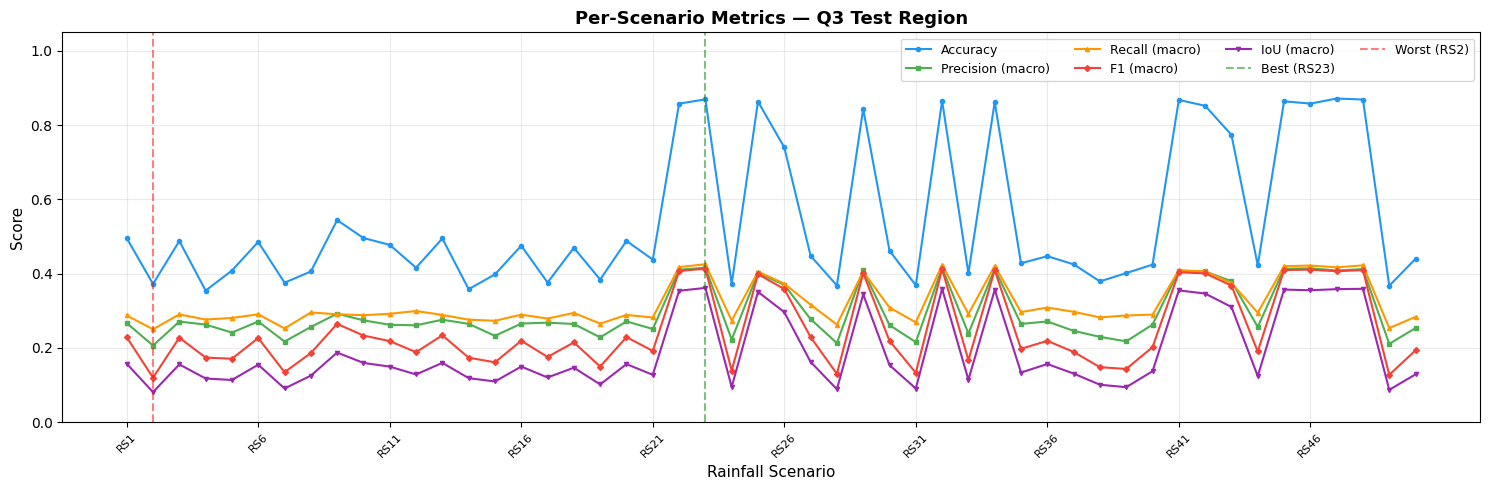

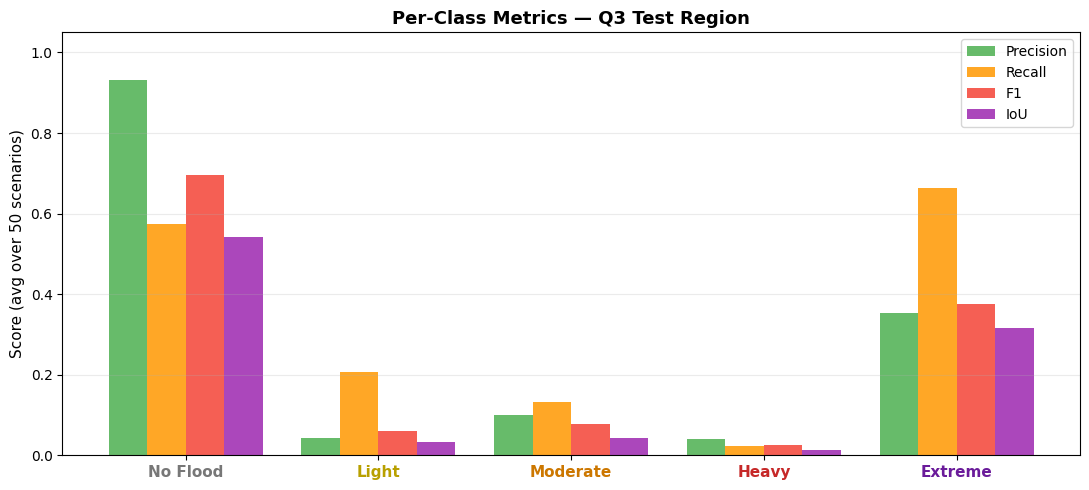

In [18]:
print("\nGenerating visualizations...")

fig1 = plot_metrics_summary(results)
fig1.savefig("eval_metrics_summary.png", dpi=150, bbox_inches='tight')

fig2 = plot_per_scenario_metrics(results)
fig2.savefig("eval_per_scenario.png", dpi=150, bbox_inches='tight')

fig3 = plot_per_class_metrics(results)
fig3.savefig("eval_per_class.png", dpi=150, bbox_inches='tight')

plt.show()

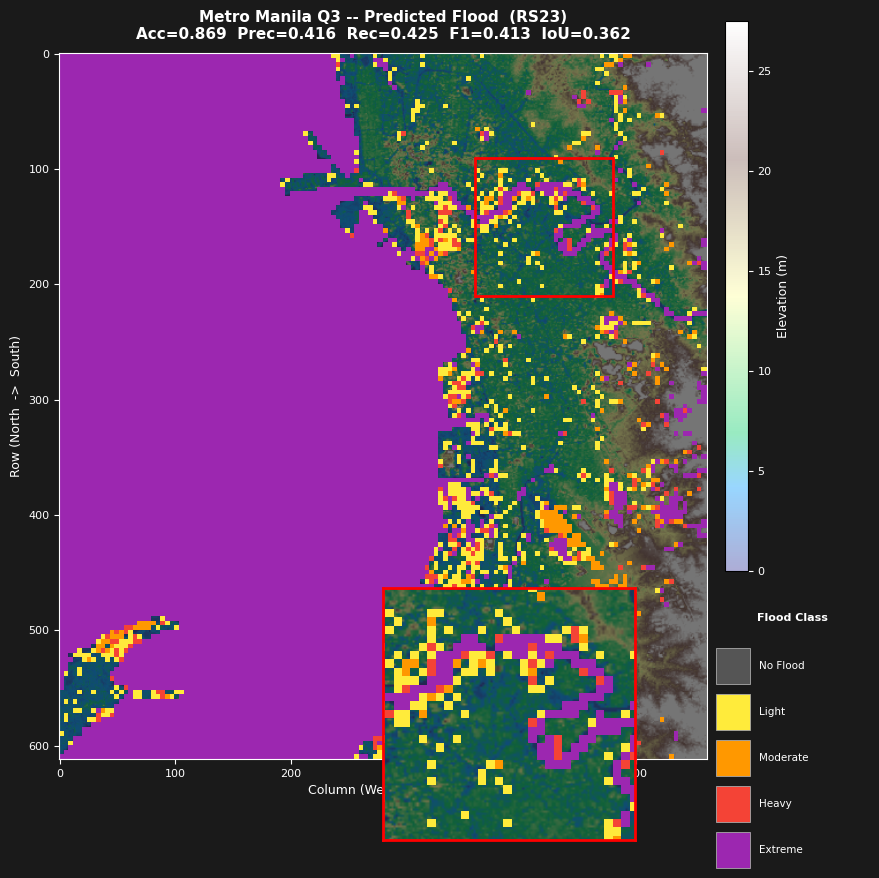

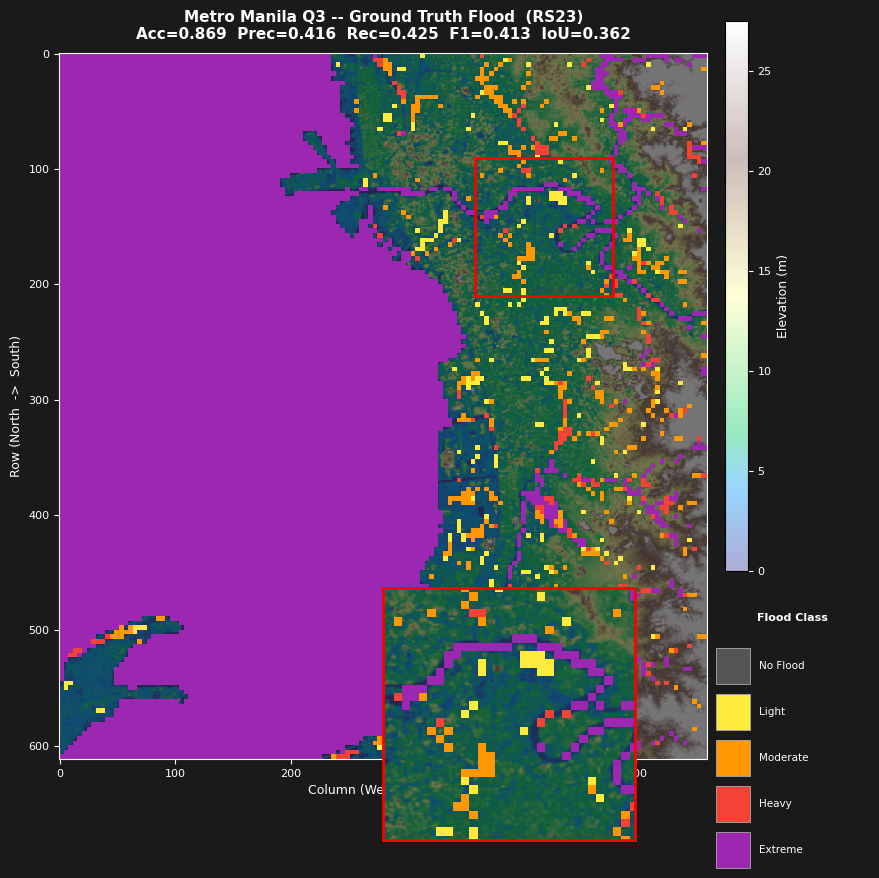


All figures saved.
  Best  scenario: RS23
  Worst scenario: RS2


In [19]:
H_dem, W_dem = dem_clean.shape
dem_q3 = dem_clean[H_dem//2:, :W_dem//2]   # bottom-left = Q3

best_idx  = results['aggregate']['best_scenario']  - 1
worst_idx = results['aggregate']['worst_scenario'] - 1

# Single scenario — predicted
fig4 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['pred_maps'][best_idx],
    scenario_id = results['aggregate']['best_scenario'],
    metrics     = results['per_scenario'][best_idx],
    mode        = 'pred',
    inset_center= (150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig4.savefig("eval_dem_best_pred.png", dpi=150, bbox_inches='tight')

# Single scenario — ground truth
fig5 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['gt_maps'][best_idx],
    scenario_id = results['aggregate']['best_scenario'],
    metrics     = results['per_scenario'][best_idx],
    mode        = 'gt',
    inset_center=(150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig5.savefig("eval_dem_best_gt.png", dpi=150, bbox_inches='tight')

plt.show()
print("\nAll figures saved.")
print(f"  Best  scenario: RS{results['aggregate']['best_scenario']}")
print(f"  Worst scenario: RS{results['aggregate']['worst_scenario']}")

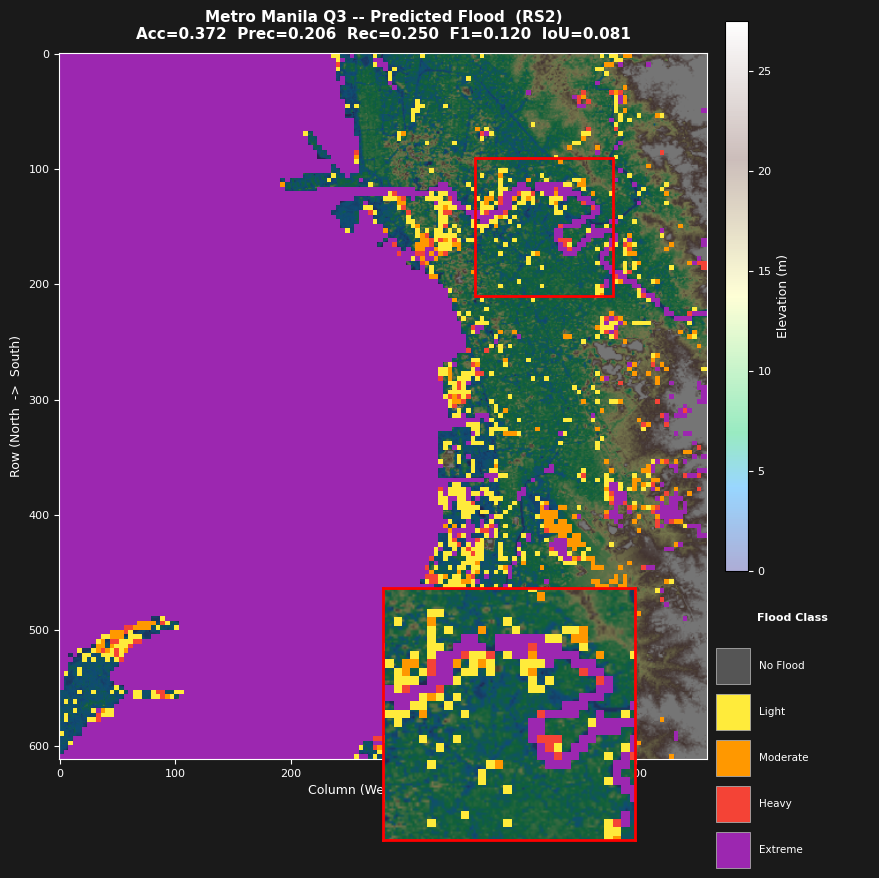

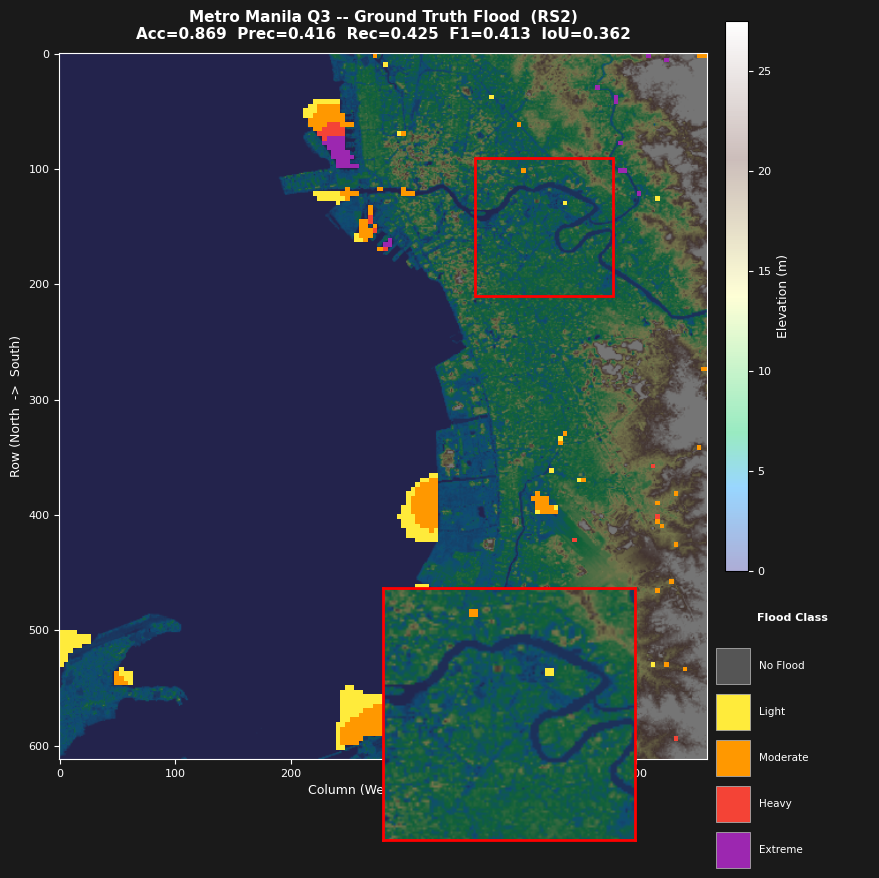

In [20]:
# WORST SCENARIO
# Single scenario — predicted
fig4 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['pred_maps'][worst_idx],
    scenario_id = results['aggregate']['worst_scenario'],
    metrics     = results['per_scenario'][worst_idx],
    mode        = 'pred',
    inset_center= (150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig4.savefig("eval_dem_worst_pred.png", dpi=150, bbox_inches='tight')

# Single scenario — ground truth
fig5 = plot_flood_on_dem(
    dem_q3      = dem_q3,
    flood_map   = results['gt_maps'][worst_idx],
    scenario_id = results['aggregate']['worst_scenario'],
    metrics     = results['per_scenario'][best_idx],
    mode        = 'gt',
    inset_center=(150, 420),
    figsize     = (9, 11),
    inset_size  = 60
)
fig5.savefig("eval_dem_worst_gt.png", dpi=150, bbox_inches='tight')